# SDV PAR Synthesizer - Depression Dataset (Time Series)
This notebook uses PARSynthesizer from SDV to generate synthetic time series data.

In [1]:
# Load libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sdv.sequential import PARSynthesizer
from sdv.metadata import SingleTableMetadata
from matplotlib import pyplot as plt

In [2]:
FUNCTIONS_HOME = '../../../functions/evaluation_functions/'
REAL_DATA_HOME = '../../../data/raw/rembrandt/'
SYN_DATA_HOME  = '../../../data/processed/rembrandt/'
TRAIN_FILE = '0_Depression_Data_Real_Train_Long.csv'
SYNTHETIC_FILE = '0_Depression_Data_Synthetic_SDV.csv'

## 1. Read data (Long format)

In [3]:
# Read long format data
real_data = pd.read_csv(REAL_DATA_HOME + TRAIN_FILE)
print(f"Data shape: {real_data.shape}")
print(f"Number of subjects: {real_data['subject'].nunique()}")
print(f"Time points per subject: {real_data.groupby('subject').size().iloc[0]}")
real_data.head(20)

Data shape: (1344, 5)
Number of subjects: 96
Time points per subject: 14


,subject,group,timestamp,ma,hars
0,1,Control,1,-0.872369,-0.943320
1,1,Control,2,-0.872369,-0.943320
2,1,Control,3,-0.872369,-1.130271
3,1,Control,4,-0.872369,-0.943320
4,1,Control,5,-0.872369,-1.130271
5,1,Control,6,-0.872369,-0.756370
6,1,Control,7,-0.872369,-1.130271
7,1,Control,8,-0.684762,-0.943320
8,1,Control,9,-0.872369,-1.130271
9,1,Control,10,-0.872369,-0.943320


In [4]:
real_data.dtypes

subject        int64
group         object
timestamp      int64
ma           float64
hars         float64
dtype: object

## 2. Create metadata for time series

In [5]:
# Create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

# IMPORTANT: Set subject as 'id' type BEFORE setting it as sequence_key
metadata.update_column(column_name='subject', sdtype='id')
metadata.update_column(column_name='group', sdtype='categorical')
metadata.update_column(column_name='ma', sdtype='numerical')
metadata.update_column(column_name='hars', sdtype='numerical')

# Set sequence key (identifies different sequences/subjects)
metadata.set_sequence_key(column_name='subject')

# Set sequence index (time order)
metadata.set_sequence_index(column_name='timestamp')

print("Metadata configuration:")
metadata.to_dict()

Metadata configuration:


{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'subject': {'sdtype': 'id'},
  'group': {'sdtype': 'categorical'},
  'timestamp': {'sdtype': 'numerical'},
  'ma': {'sdtype': 'numerical'},
  'hars': {'sdtype': 'numerical'}},
 'sequence_key': 'subject',
 'sequence_index': 'timestamp'}

## 3. Train the model and generate data

In [6]:
synthesizer = PARSynthesizer(
    metadata=metadata,
    epochs=800,
    sample_size=14,   # 或 7
    cuda=True,
    verbose=True,
    context_columns=['group']  # 指定group为不随时间变化的列
)
synthesizer.fit(real_data)

Loss (-0.058): 100%|██████████| 800/800 [00:33<00:00, 23.87it/s]


In [7]:
num_subjects = real_data['subject'].nunique()
num_subjects

96

In [8]:
# Generate synthetic data
# Generate same number of sequences as original data
num_subjects = real_data['subject'].nunique()
print(f"Generating {num_subjects} synthetic sequences...")

# IMPORTANT: Specify sequence_length to ensure all sequences have 14 time points
synthetic_data_long = synthesizer.sample(
    num_sequences=num_subjects,
    sequence_length=14  # Fix sequence length to match original data
)
print(f"Synthetic data shape: {synthetic_data_long.shape}")
print(f"\nMissing values check:")
print(synthetic_data_long.isnull().sum())
print(f"\nSequence lengths:")
print(synthetic_data_long.groupby('subject').size().value_counts())
synthetic_data_long.head(20)

Generating 96 synthetic sequences...


100%|██████████| 96/96 [00:07<00:00, 12.10it/s]

Synthetic data shape: (1344, 5)

Missing values check:
subject      0
group        0
timestamp    0
ma           0
hars         0
dtype: int64

Sequence lengths:
14    96
Name: count, dtype: int64


,subject,group,timestamp,ma,hars
0,13051783,Control,1,-0.458742,-1.130271
1,13051783,Control,2,-0.617009,-0.591046
2,13051783,Control,3,-0.445561,-0.778372
3,13051783,Control,4,-0.811769,-0.633787
4,13051783,Control,5,-0.642048,-0.657882
5,13051783,Control,6,-0.872369,-0.693434
6,13051783,Control,7,-0.419635,-1.130271
7,13051783,Control,8,-0.872369,-0.064888
8,13051783,Control,9,-0.483581,-0.875779
9,13051783,Control,10,-0.872369,-0.435070


## 4. Compare statistics

In [9]:
print("Real data statistics:")
real_data.describe()

Real data statistics:


,subject,timestamp,ma,hars
count,1344.000000,1344.000000,1344.000000,1344.000000
mean,48.500000,7.500000,0.020575,0.035804
std,27.721624,4.032629,0.999996,1.000123
min,1.000000,1.000000,-0.872369,-1.130271
25%,24.750000,4.000000,-0.684762,-0.756370
50%,48.500000,7.500000,-0.309550,-0.195519
75%,72.250000,11.000000,0.440874,0.552282
max,96.000000,14.000000,5.506240,4.291289


In [10]:
print("Synthetic data statistics:")
synthetic_data_long.describe()

Synthetic data statistics:


,subject,timestamp,ma,hars
count,1.344000e+03,1344.000000,1344.000000,1344.000000
mean,9.380645e+06,7.500000,-0.314397,-0.351079
std,4.614455e+06,4.032629,0.583154,0.668429
min,1.263290e+05,1.000000,-0.872369,-1.130271
25%,5.639580e+06,4.000000,-0.791703,-0.893382
50%,9.531441e+06,7.500000,-0.485011,-0.452506
75%,1.322731e+07,11.000000,-0.029465,0.042816
max,1.667296e+07,14.000000,2.959696,2.804297


In [11]:
# Compare group distribution
print("Real data group distribution:")
print(real_data.groupby('subject')['group'].first().value_counts())

print("\nSynthetic data group distribution:")
print(synthetic_data_long.groupby('subject')['group'].first().value_counts())

Real data group distribution:
group
Remitted    65
Control     31
Name: count, dtype: int64

Synthetic data group distribution:
group
Remitted    63
Control     33
Name: count, dtype: int64


## 5. Visualize time series patterns

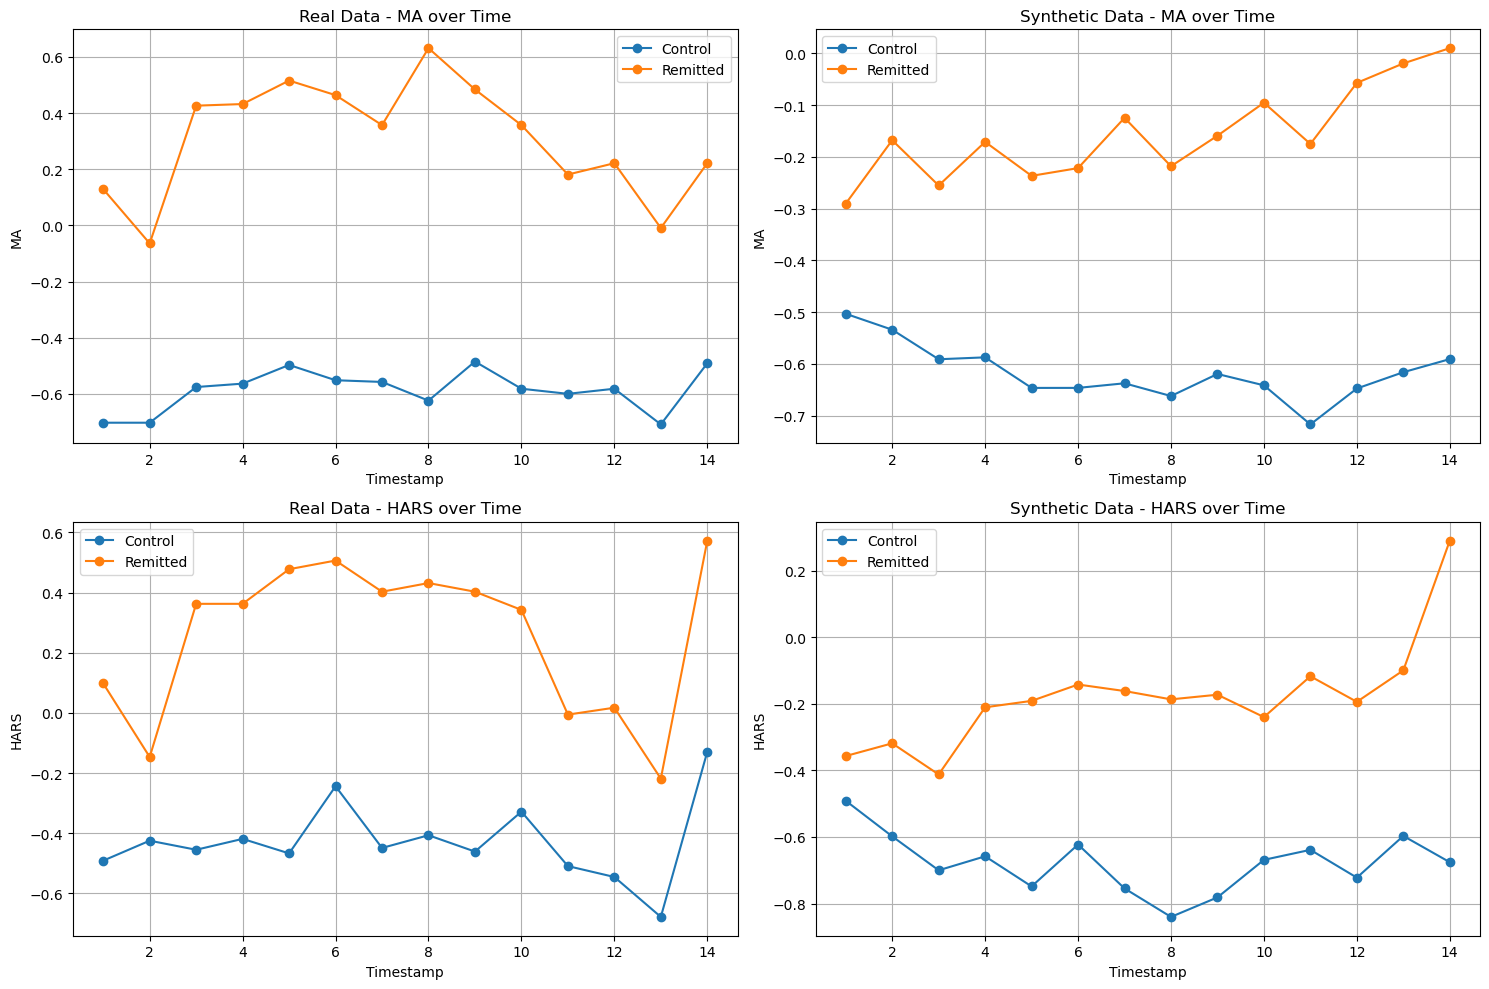

In [12]:
# Plot average trajectories by group
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Real data - MA
real_grouped = real_data.groupby(['group', 'timestamp'])['ma'].mean().reset_index()
for group in real_grouped['group'].unique():
    data = real_grouped[real_grouped['group'] == group]
    axes[0, 0].plot(data['timestamp'], data['ma'], marker='o', label=group)
axes[0, 0].set_title('Real Data - MA over Time')
axes[0, 0].set_xlabel('Timestamp')
axes[0, 0].set_ylabel('MA')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Synthetic data - MA
synth_grouped = synthetic_data_long.groupby(['group', 'timestamp'])['ma'].mean().reset_index()
for group in synth_grouped['group'].unique():
    data = synth_grouped[synth_grouped['group'] == group]
    axes[0, 1].plot(data['timestamp'], data['ma'], marker='o', label=group)
axes[0, 1].set_title('Synthetic Data - MA over Time')
axes[0, 1].set_xlabel('Timestamp')
axes[0, 1].set_ylabel('MA')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Real data - HARS
real_grouped = real_data.groupby(['group', 'timestamp'])['hars'].mean().reset_index()
for group in real_grouped['group'].unique():
    data = real_grouped[real_grouped['group'] == group]
    axes[1, 0].plot(data['timestamp'], data['hars'], marker='o', label=group)
axes[1, 0].set_title('Real Data - HARS over Time')
axes[1, 0].set_xlabel('Timestamp')
axes[1, 0].set_ylabel('HARS')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Synthetic data - HARS
synth_grouped = synthetic_data_long.groupby(['group', 'timestamp'])['hars'].mean().reset_index()
for group in synth_grouped['group'].unique():
    data = synth_grouped[synth_grouped['group'] == group]
    axes[1, 1].plot(data['timestamp'], data['hars'], marker='o', label=group)
axes[1, 1].set_title('Synthetic Data - HARS over Time')
axes[1, 1].set_xlabel('Timestamp')
axes[1, 1].set_ylabel('HARS')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 6. Convert back to wide format (optional)

In [13]:
# Convert synthetic data back to wide format
synthetic_data_wide = synthetic_data_long.pivot(
    index=['subject', 'group'], 
    columns='timestamp', 
    values=['ma', 'hars']
).reset_index()

# Flatten column names
synthetic_data_wide.columns = ['subject', 'group'] + \
    [f'{col[0]}{col[1]}' for col in synthetic_data_wide.columns[2:]]

# Reorder columns to match original format
columns_order = ['group']
for i in range(1, 15):
    columns_order.extend([f'ma{i}', f'hars{i}'])

synthetic_data_wide = synthetic_data_wide[columns_order]

print(f"Wide format shape: {synthetic_data_wide.shape}")
synthetic_data_wide.head()

Wide format shape: (96, 29)


,group,ma1,hars1,ma2,hars2,ma3,hars3,ma4,hars4,ma5,...,ma10,hars10,ma11,hars11,ma12,hars12,ma13,hars13,ma14,hars14
0,Control,-0.526552,-0.503796,-0.126666,-0.945849,-0.626173,-0.726882,-0.736136,-0.224037,-0.872369,...,-0.699358,-1.130271,-0.872369,-0.420513,-0.781141,-1.130271,-0.768524,-0.431702,-0.496995,0.298801
1,Remitted,0.499846,-1.050591,-0.784461,-0.440538,-0.872369,-0.403508,-0.443969,0.325958,-0.559629,...,0.133816,0.054624,-0.021047,-0.283188,-0.062218,-0.152891,0.031533,-0.673691,-0.486443,0.902377
2,Control,-0.650528,-0.567976,-0.109932,-1.130271,-0.872369,-0.708940,-0.640638,-1.086052,-0.872369,...,-0.759087,-0.716348,-0.842848,0.057614,-0.776351,-1.130271,-0.862435,-0.536475,-0.584379,-0.092364
3,Remitted,-0.483030,0.136977,0.071759,-0.748899,-0.332061,-1.130271,-0.872369,-0.727835,-0.574798,...,-0.872369,-0.402823,-0.715093,0.401735,0.056658,-0.996791,0.652423,-0.460742,0.087988,0.484143
4,Remitted,-0.555929,0.308327,0.127175,-1.130271,-0.872369,-1.130271,-0.361144,-0.394663,-0.196802,...,-0.004736,0.091620,-0.545564,0.700549,1.158322,-0.619900,-0.135528,-0.135439,0.714020,2.101786


## 7. Save synthetic data

In [14]:
# Save long format
synthetic_data_wide.to_csv(SYN_DATA_HOME + SYNTHETIC_FILE, index=False)
print(f"Long format saved to: {SYNTHETIC_FILE}")

Long format saved to: SYNTHETIC DATASETS/SDV/0_Depression_Data_Synthetic_SDV.csv
